In [ ]:
import os
import shutil
import re
import random
import kagglehub
os.environ["KAGGLE_API_TOKEN"] = "KGAT_4cc4698f452264be817b7651aa49ffac"

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
import warnings
warnings.filterwarnings("ignore")

In [ ]:
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout
from tensorflow.keras.models import Model,load_model
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications.efficientnet import preprocess_input
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau

In [ ]:
# Download latest version
dataset1 = kagglehub.dataset_download("lukex9442/indian-bovine-breeds")

print("Path to dataset files:", dataset1)

100%|██████████| 2.84G/2.84G [00:25<00:00, 121MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/lukex9442/indian-bovine-breeds/versions/5


In [ ]:
# Download latest version
dataset2 = kagglehub.dataset_download("atharvadarpude/indian-buffalo-dataset")

print("Path to dataset files:", dataset2)

100%|██████████| 38.4M/38.4M [00:00<00:00, 161MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/atharvadarpude/indian-buffalo-dataset/versions/1


In [ ]:
# Download datasets
dataset1 = kagglehub.dataset_download("lukex9442/indian-bovine-breeds")
dataset2 = kagglehub.dataset_download("atharvadarpude/indian-buffalo-dataset")

print("Dataset1:", dataset1)
print("Dataset2:", dataset2)

# Fix paths according to dataset structure
dataset1 = os.path.join(dataset1, "Indian_bovine_breeds", "Indian_bovine_breeds")
dataset2 = os.path.join(dataset2, "buffalo")

# Final merged dataset
final_dataset = "final_dataset"
os.makedirs(final_dataset, exist_ok=True)

def normalize(name):
    name = name.lower()
    name = name.replace(" ", "_")
    name = name.replace("-", "_")
    name = re.sub(r'[^a-z0-9_]', '', name)
    return name

def merge_dataset(source):

    for breed in os.listdir(source):

        breed_path = os.path.join(source, breed)

        if not os.path.isdir(breed_path):
            continue

        breed_name = normalize(breed)

        final_breed_path = os.path.join(final_dataset, breed_name)
        os.makedirs(final_breed_path, exist_ok=True)

        for img in os.listdir(breed_path):

            src = os.path.join(breed_path, img)

            if not os.path.isfile(src):
                continue

            dst = os.path.join(final_breed_path, img)

            if os.path.exists(dst):
                name, ext = os.path.splitext(img)
                dst = os.path.join(final_breed_path, name + "_copy" + ext)

            shutil.copy2(src, dst)

merge_dataset(dataset1)
merge_dataset(dataset2)

print("Datasets merged successfully!")

Dataset1: /root/.cache/kagglehub/datasets/lukex9442/indian-bovine-breeds/versions/5
Dataset2: /root/.cache/kagglehub/datasets/atharvadarpude/indian-buffalo-dataset/versions/1
Datasets merged successfully!


In [ ]:
import shutil

shutil.make_archive(
    "/kaggle/working/final_dataset",
    'zip',
    "/kaggle/working/final_dataset"
)

In [ ]:
dataset = "final_dataset"

for breed in sorted(os.listdir(dataset)):
    path = os.path.join(dataset, breed)
    if os.path.isdir(path):
        print(breed, ":", len(os.listdir(path)))

alambadi : 99
amritmahal : 94
ayrshire : 234
banni : 236
bargur : 217
bhadawari : 86
bhadwari : 148
brown_swiss : 225
chhattisgarhi : 131
chilika : 144
dangi : 82
deoni : 99
gir : 372
gojri : 177
guernsey : 119
hallikar : 186
hariana : 130
holstein_friesian : 328
jaffarabadi : 357
jaffrabadi : 102
jersey : 203
kalahandi : 67
kangayam : 91
kankrej : 179
kasargod : 95
kenkatha : 55
kherigarh : 36
khillari : 113
krishna_valley : 136
luit : 129
malnad_gidda : 107
marathwada : 172
mehsana : 163
murrah : 499
nagori : 89
nagpuri : 343
nili_ravi : 278
nimari : 84
ongole : 191
pandharpuri : 141
pulikulam : 125
rathi : 149
red_dane : 167
red_sindhi : 166
sahiwal : 439
surti : 234
tharparkar : 217
toda : 285
umblachery : 76
vechur : 140


In [ ]:
selected_breeds = [
    "gir","sahiwal","ongole","kankrej","tharparkar","hallikar",
    "jersey","holstein_friesian","brown_swiss",
    "murrah","nagpuri","jaffarabadi","nili_ravi","surti","mehsana"
]

In [ ]:
source_dataset = "final_dataset"
filtered_dataset = "filtered_dataset"

# Remove filtered_dataset if it exists to ensure a clean start
if os.path.exists(filtered_dataset):
    shutil.rmtree(filtered_dataset)

os.makedirs(filtered_dataset, exist_ok=True)

for breed in selected_breeds:

    src = os.path.join(source_dataset, breed)
    dst = os.path.join(filtered_dataset, breed)

    if os.path.exists(src):
        shutil.copytree(src, dst)

print("Filtered dataset created!")

Filtered dataset created!


In [ ]:
dataset = "filtered_dataset"

train_dir = "dataset/train"
val_dir = "dataset/val"

os.makedirs(train_dir, exist_ok=True)
os.makedirs(val_dir, exist_ok=True)

for breed in os.listdir(dataset):

    breed_path = os.path.join(dataset, breed)

    images = os.listdir(breed_path)
    random.shuffle(images)

    split = int(0.8 * len(images))

    train_imgs = images[:split]
    val_imgs = images[split:]

    os.makedirs(os.path.join(train_dir, breed), exist_ok=True)
    os.makedirs(os.path.join(val_dir, breed), exist_ok=True)

    for img in train_imgs:
        shutil.copy(os.path.join(breed_path, img),
                    os.path.join(train_dir, breed, img))

    for img in val_imgs:
        shutil.copy(os.path.join(breed_path, img),
                    os.path.join(val_dir, breed, img))
print("Train and Validation data separated")

Train and Validation data separated


AUGMENTATION OF DATA

In [ ]:
train_dir = "dataset/train"
val_dir = "dataset/val"

train_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    rotation_range=15,
    zoom_range=0.15,
    horizontal_flip=True
)

val_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input
)

In [ ]:
train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=(224,224),
    batch_size=32,
    class_mode='categorical'
)

val_generator = val_datagen.flow_from_directory(
    val_dir,
    target_size=(224,224),
    batch_size=32,
    class_mode='categorical'
)

Found 3354 images belonging to 15 classes.
Found 847 images belonging to 15 classes.


In [ ]:
# from sklearn.utils.class_weight import compute_class_weight
# import numpy as np

# classes = np.unique(train_generator.classes)

# class_weights = compute_class_weight(
#     class_weight='balanced',
#     classes=classes,
#     y=train_generator.classes
# )

# class_weights = dict(enumerate(class_weights))

# print(class_weights)

In [ ]:
print(train_generator.num_classes)

15


In [ ]:
print(train_generator.class_indices)

{'brown_swiss': 0, 'gir': 1, 'hallikar': 2, 'holstein_friesian': 3, 'jaffarabadi': 4, 'jersey': 5, 'kankrej': 6, 'mehsana': 7, 'murrah': 8, 'nagpuri': 9, 'nili_ravi': 10, 'ongole': 11, 'sahiwal': 12, 'surti': 13, 'tharparkar': 14}


In [ ]:
x, y = next(train_generator)
print(x.shape)
print(y.shape)

(32, 224, 224, 3)
(32, 15)


TRANSFER LEARNING

In [ ]:
num_classes = train_generator.num_classes

base_model = EfficientNetB0(
    weights='imagenet',
    include_top=False,
    input_shape=(224,224,3)
)

x = base_model.output
x = GlobalAveragePooling2D()(x)

x = Dense(512, activation='relu')(x)
x = Dropout(0.5)(x)

x = Dense(256, activation='relu')(x)
x = Dropout(0.3)(x)

outputs = Dense(num_classes, activation='softmax')(x)

model = Model(inputs=base_model.input, outputs=outputs)

16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [ ]:
for layer in base_model.layers:
    layer.trainable = False

In [ ]:
model.compile(
    optimizer=Adam(learning_rate=1e-4),
    loss = "categorical_crossentropy",
    metrics=['accuracy']
)

In [ ]:
checkpoint = ModelCheckpoint(
    "best_model.h5",
    monitor="val_accuracy",
    save_best_only=True,
    verbose=1
)

early_stop = EarlyStopping(
    monitor="val_loss",
    patience=3,
    restore_best_weights=True
)

lr_reduce = ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.3,
    patience=2,
    min_lr=1e-6
)

In [ ]:
history = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=20,
    verbose = 1,
    callbacks=[checkpoint, early_stop, lr_reduce]
)

Epoch 1/20
105/105 ━━━━━━━━━━━━━━━━━━━━ 0s 749ms/step - accuracy: 0.1548 - loss: 2.6436
Epoch 1: val_accuracy improved from -inf to 0.39315, saving model to best_model.h5


105/105 ━━━━━━━━━━━━━━━━━━━━ 135s 1s/step - accuracy: 0.1555 - loss: 2.6418 - val_accuracy: 0.3932 - val_loss: 2.0011 - learning_rate: 1.0000e-04
Epoch 2/20
105/105 ━━━━━━━━━━━━━━━━━━━━ 0s 585ms/step - accuracy: 0.3438 - loss: 2.0097
Epoch 2: val_accuracy improved from 0.39315 to 0.49941, saving model to best_model.h5


105/105 ━━━━━━━━━━━━━━━━━━━━ 69s 660ms/step - accuracy: 0.3442 - loss: 2.0088 - val_accuracy: 0.4994 - val_loss: 1.5839 - learning_rate: 1.0000e-04
Epoch 3/20
105/105 ━━━━━━━━━━━━━━━━━━━━ 0s 582ms/step - accuracy: 0.4366 - loss: 1.6655
Epoch 3: val_accuracy improved from 0.49941 to 0.55962, saving model to best_model.h5


105/105 ━━━━━━━━━━━━━━━━━━━━ 69s 659ms/step - accuracy: 0.4367 - loss: 1.6652 - val_accuracy: 0.5596 - val_loss: 1.3812 - learning_rate: 1.0000e-04
Epoch 4/20
105/105 ━━━━━━━━━━━━━━━━━━━━ 0s 585ms/step - accuracy: 0.5040 - loss: 1.5074
Epoch 4: val_accuracy improved from 0.55962 to 0.58796, saving model to best_model.h5


105/105 ━━━━━━━━━━━━━━━━━━━━ 69s 656ms/step - accuracy: 0.5041 - loss: 1.5071 - val_accuracy: 0.5880 - val_loss: 1.2663 - learning_rate: 1.0000e-04
Epoch 5/20
105/105 ━━━━━━━━━━━━━━━━━━━━ 0s 586ms/step - accuracy: 0.5279 - loss: 1.4149
Epoch 5: val_accuracy improved from 0.58796 to 0.60213, saving model to best_model.h5


...

105/105 ━━━━━━━━━━━━━━━━━━━━ 70s 668ms/step - accuracy: 0.6590 - loss: 1.0465 - val_accuracy: 0.6682 - val_loss: 1.0070 - learning_rate: 1.0000e-04
Epoch 14/20
105/105 ━━━━━━━━━━━━━━━━━━━━ 0s 583ms/step - accuracy: 0.6541 - loss: 1.0080
Epoch 14: val_accuracy improved from 0.66824 to 0.66942, saving model to best_model.h5


105/105 ━━━━━━━━━━━━━━━━━━━━ 70s 670ms/step - accuracy: 0.6543 - loss: 1.0077 - val_accuracy: 0.6694 - val_loss: 0.9920 - learning_rate: 1.0000e-04
Epoch 15/20
105/105 ━━━━━━━━━━━━━━━━━━━━ 0s 595ms/step - accuracy: 0.6517 - loss: 0.9958
Epoch 15: val_accuracy did not improve from 0.66942
105/105 ━━━━━━━━━━━━━━━━━━━━ 70s 669ms/step - accuracy: 0.6518 - loss: 0.9955 - val_accuracy: 0.6600 - val_loss: 0.9865 - learning_rate: 1.0000e-04
Epoch 16/20
105/105 ━━━━━━━━━━━━━━━━━━━━ 0s 575ms/step - accuracy: 0.6929 - loss: 0.9163
Epoch 16: val_accuracy improved from 0.66942 to 0.68123, saving model to best_model.h5


105/105 ━━━━━━━━━━━━━━━━━━━━ 69s 654ms/step - accuracy: 0.6927 - loss: 0.9164 - val_accuracy: 0.6812 - val_loss: 0.9725 - learning_rate: 1.0000e-04
Epoch 17/20
105/105 ━━━━━━━━━━━━━━━━━━━━ 0s 588ms/step - accuracy: 0.6920 - loss: 0.9015
Epoch 17: val_accuracy did not improve from 0.68123
105/105 ━━━━━━━━━━━━━━━━━━━━ 69s 660ms/step - accuracy: 0.6920 - loss: 0.9017 - val_accuracy: 0.6812 - val_loss: 0.9601 - learning_rate: 1.0000e-04
Epoch 18/20
105/105 ━━━━━━━━━━━━━━━━━━━━ 0s 571ms/step - accuracy: 0.6932 - loss: 0.9066
Epoch 18: val_accuracy improved from 0.68123 to 0.68241, saving model to best_model.h5


105/105 ━━━━━━━━━━━━━━━━━━━━ 69s 650ms/step - accuracy: 0.6933 - loss: 0.9066 - val_accuracy: 0.6824 - val_loss: 0.9522 - learning_rate: 1.0000e-04
Epoch 19/20
105/105 ━━━━━━━━━━━━━━━━━━━━ 0s 581ms/step - accuracy: 0.7022 - loss: 0.8861
Epoch 19: val_accuracy did not improve from 0.68241
105/105 ━━━━━━━━━━━━━━━━━━━━ 68s 649ms/step - accuracy: 0.7021 - loss: 0.8862 - val_accuracy: 0.6824 - val_loss: 0.9468 - learning_rate: 1.0000e-04
Epoch 20/20
105/105 ━━━━━━━━━━━━━━━━━━━━ 0s 582ms/step - accuracy: 0.7161 - loss: 0.8327
Epoch 20: val_accuracy improved from 0.68241 to 0.68831, saving model to best_model.h5


105/105 ━━━━━━━━━━━━━━━━━━━━ 70s 663ms/step - accuracy: 0.7160 - loss: 0.8329 - val_accuracy: 0.6883 - val_loss: 0.9422 - learning_rate: 1.0000e-04


In [ ]:
from tensorflow.keras.models import load_model

model = load_model("best_model.h5")

FINE TUNING

In [ ]:
for layer in base_model.layers[-20:]:
    layer.trainable = True

In [ ]:
model.compile(
    optimizer=Adam(learning_rate=1e-5),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [ ]:
history_fine = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=5,
    callbacks=[early_stop, lr_reduce],
    verbose = 1
)

Epoch 1/5
105/105 ━━━━━━━━━━━━━━━━━━━━ 113s 871ms/step - accuracy: 0.7205 - loss: 0.8293 - val_accuracy: 0.6848 - val_loss: 0.9392 - learning_rate: 1.0000e-05
Epoch 2/5
105/105 ━━━━━━━━━━━━━━━━━━━━ 69s 654ms/step - accuracy: 0.7009 - loss: 0.8681 - val_accuracy: 0.6871 - val_loss: 0.9383 - learning_rate: 1.0000e-05
Epoch 3/5
105/105 ━━━━━━━━━━━━━━━━━━━━ 69s 654ms/step - accuracy: 0.7405 - loss: 0.8063 - val_accuracy: 0.6895 - val_loss: 0.9392 - learning_rate: 1.0000e-05
Epoch 4/5
105/105 ━━━━━━━━━━━━━━━━━━━━ 72s 681ms/step - accuracy: 0.7082 - loss: 0.8462 - val_accuracy: 0.6919 - val_loss: 0.9367 - learning_rate: 1.0000e-05
Epoch 5/5
105/105 ━━━━━━━━━━━━━━━━━━━━ 68s 652ms/step - accuracy: 0.7214 - loss: 0.8356 - val_accuracy: 0.6895 - val_loss: 0.9364 - learning_rate: 1.0000e-05


In [ ]:
os.makedirs('/kaggle/working', exist_ok=True)
model.save("/kaggle/working/cattle_breed_model.keras")

In [ ]:
import os
os.listdir("/kaggle/working")

['cattle_breed_model.keras']

In [ ]:
model = load_model("/kaggle/working/cattle_breed_model.keras")

IF RUNTIME REGENERATED

In [ ]:
# from tensorflow.keras.preprocessing.image import ImageDataGenerator
# from tensorflow.keras.applications.efficientnet import preprocess_input

# val_datagen = ImageDataGenerator(
#     preprocessing_function=preprocess_input
# )

# val_generator = val_datagen.flow_from_directory(
#     val_dir,
#     target_size=(224,224),
#     batch_size=32,
#     class_mode='categorical',
#     shuffle=False
# )

In [ ]:
loss, acc = model.evaluate(val_generator)

print("Validation Accuracy:", acc)

27/27 ━━━━━━━━━━━━━━━━━━━━ 8s 299ms/step - accuracy: 0.6921 - loss: 0.9602
Validation Accuracy: 0.6894923448562622


In [ ]:
loss, acc = model.evaluate(train_generator)

print( "Training Accuracy:", acc)

105/105 ━━━━━━━━━━━━━━━━━━━━ 72s 691ms/step - accuracy: 0.8002 - loss: 0.6199
Training Accuracy: 0.7954680919647217


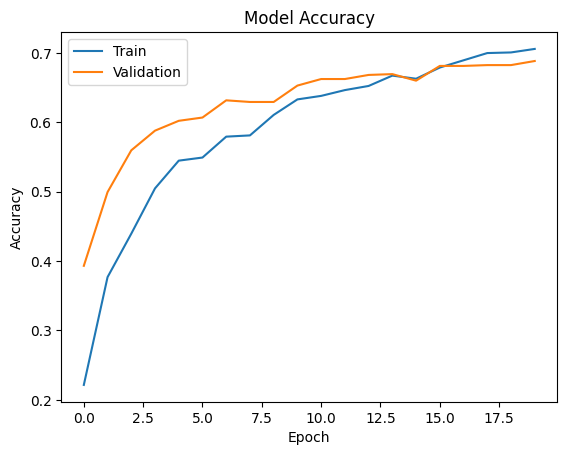

In [ ]:
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])

plt.title("Model Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")

plt.legend(["Train", "Validation"])
plt.show()

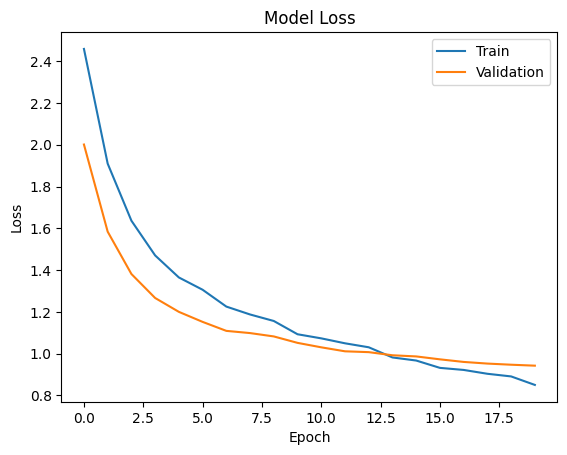

In [ ]:
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])

plt.title("Model Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.legend(["Train", "Validation"])
plt.show()

In [ ]:
from sklearn.metrics import confusion_matrix,classification_report

27/27 ━━━━━━━━━━━━━━━━━━━━ 8s 289ms/step


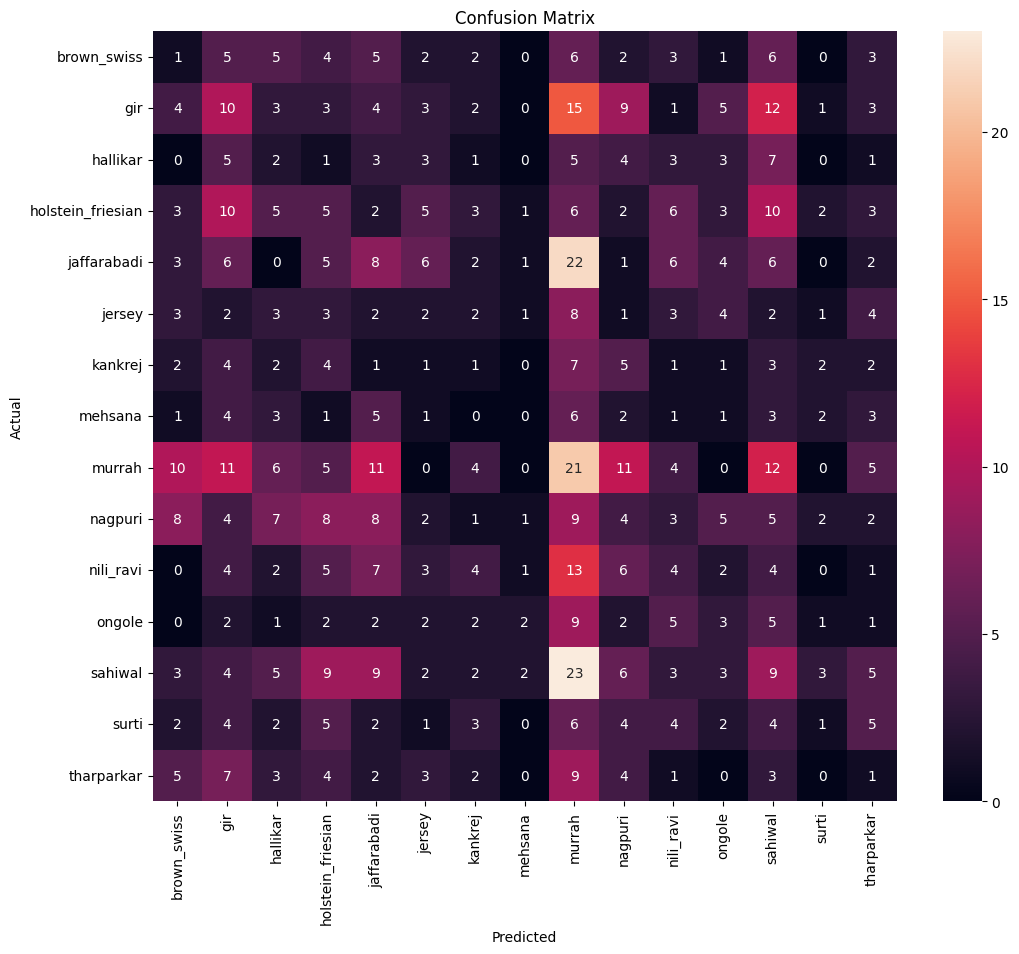

In [ ]:
pred = model.predict(val_generator)
y_pred = np.argmax(pred, axis=1)

cm = confusion_matrix(val_generator.classes, y_pred)

plt.figure(figsize=(12,10))
sns.heatmap(cm, annot=True, fmt="d",
            xticklabels=val_generator.class_indices.keys(),
            yticklabels=val_generator.class_indices.keys())

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

In [ ]:
print(classification_report(
    val_generator.classes,
    y_pred,
    target_names=list(val_generator.class_indices.keys())
))

                   precision    recall  f1-score   support

      brown_swiss       0.02      0.02      0.02        45
              gir       0.12      0.13      0.13        75
         hallikar       0.04      0.05      0.05        38
holstein_friesian       0.08      0.08      0.08        66
      jaffarabadi       0.11      0.11      0.11        72
           jersey       0.06      0.05      0.05        41
          kankrej       0.03      0.03      0.03        36
          mehsana       0.00      0.00      0.00        33
           murrah       0.13      0.21      0.16       100
          nagpuri       0.06      0.06      0.06        69
        nili_ravi       0.08      0.07      0.08        56
           ongole       0.08      0.08      0.08        39
          sahiwal       0.10      0.10      0.10        88
            surti       0.07      0.02      0.03        45
       tharparkar       0.02      0.02      0.02        44

         accuracy                           0.09      

PREDICT

In [ ]:
import numpy as np
from tensorflow.keras.preprocessing import image

img_path = "/Gir_1.jfif"

img = image.load_img(img_path, target_size=(224,224))
img_array = image.img_to_array(img)
img_array = np.expand_dims(img_array, axis=0)

img_array = preprocess_input(img_array)

pred = model.predict(img_array)

predicted_class = np.argmax(pred)

labels = val_generator.class_indices
labels = dict((v,k) for k,v in labels.items())

print("Predicted Breed:", labels[predicted_class])

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step
Predicted Breed: gir


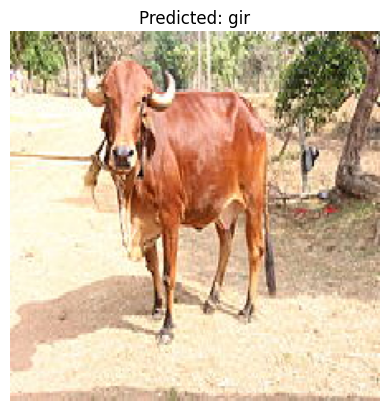

In [ ]:
plt.imshow(img)
plt.title("Predicted: " + labels[predicted_class])
plt.axis("off")
plt.show()

In [ ]:
import shutil
shutil.copy("/kaggle/working/cattle_breed_model.keras", "/kaggle/working/model_backup.keras")

'/kaggle/working/model_backup.keras'

**USING MODEL BY IMPORTING**

In [ ]:
from tensorflow.keras.models import load_model

model = load_model("/model_backup.keras")

In [ ]:
labels = [
'brown_swiss','gir','hallikar','holstein_friesian','jaffarabadi',
'jersey','kankrej','mehsana','murrah','nagpuri',
'nili_ravi','ongole','sahiwal','surti','tharparkar'
]

In [ ]:
import numpy as np
from tensorflow.keras.preprocessing import image
from tensorflow.keras.applications.efficientnet import preprocess_input

img_path = "/ongole1.jfif"

img = image.load_img(img_path, target_size=(224,224))
img_array = image.img_to_array(img)

img_array = np.expand_dims(img_array, axis=0)
img_array = preprocess_input(img_array)

pred = model.predict(img_array)

predicted_class = np.argmax(pred)

labels = [
'brown_swiss','gir','hallikar','holstein_friesian','jaffarabadi',
'jersey','kankrej','mehsana','murrah','nagpuri',
'nili_ravi','ongole','sahiwal','surti','tharparkar'
]

print("Predicted Breed:", labels[predicted_class])

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step
Predicted Breed: ongole


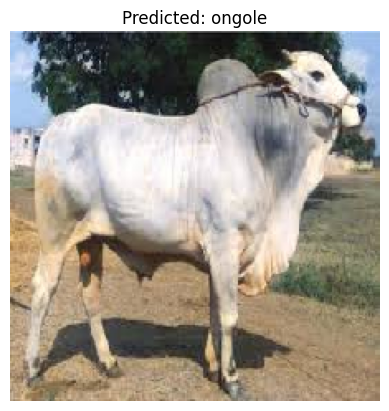

In [ ]:
import matplotlib.pyplot as plt

plt.imshow(img)
plt.title("Predicted: " + labels[predicted_class])
plt.axis("off")
plt.show()